<a href="https://colab.research.google.com/github/Dhruv-DY/CODSOFT/blob/main/Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib as mp
import seaborn as sb

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
working_dir_path = '/content/IMDb_Movies_India.csv'
mrp = pd.read_csv(working_dir_path, encoding='latin-1')

In [5]:
mrp.shape

(15509, 10)

In [6]:
mrp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [7]:
mrp.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [8]:
mrp.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [9]:
# 1. Load and view data
print(mrp.head())
print(mrp.info())
print(mrp.isnull().sum())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [10]:
# 2. Drop unimportant or highly missing columns (optional, based on actual dataset)
mrp = mrp.drop(columns=['plot_keywords', 'movie_imdb_link'], errors='ignore')

In [11]:
print(mrp.columns)

# Convert 'Duration' and 'Votes' to numeric (in case they have strings)
mrp['Duration'] = pd.to_numeric(mrp['Duration'], errors='coerce')
mrp['Votes'] = pd.to_numeric(mrp['Votes'], errors='coerce')

# Fill missing values with column means
mrp['Duration'] = mrp['Duration'].fillna(mrp['Duration'].mean())
mrp['Votes'] = mrp['Votes'].fillna(mrp['Votes'].mean())


Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [12]:
# 4. Encode categorical columns using one-hot encoding and label encoding as needed
mrp = pd.get_dummies(mrp, columns=['Genre'], drop_first=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
mrp['Director'] = le.fit_transform(mrp['Director'])
mrp['Actor 1'] = le.fit_transform(mrp['Actor 1'])
mrp['Actor 2'] = le.fit_transform(mrp['Actor 2'])
mrp['Actor 3'] = le.fit_transform(mrp['Actor 3'])

In [13]:
# 5. Define X (features) and y (target)
X = mrp.drop(['Name', 'Rating'], axis=1)
y = mrp['Rating']

In [14]:
# 6. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# 7. Train a Linear Regression model
# 4.1 Extract 4-digit year from string (removing parentheses or other non-digit chars)
mrp['Year'] = mrp['Year'].astype(str).str.extract(r'(\d{4})')

# 4.2 Convert it to numeric type (float or int)
mrp['Year'] = mrp['Year'].astype(float)


In [16]:
print(X_train.dtypes)
print(X_train.head())

Year                                 object
Duration                            float64
Votes                               float64
Director                              int64
Actor 1                               int64
                                     ...   
Genre_Thriller, Action                 bool
Genre_Thriller, Musical, Mystery       bool
Genre_Thriller, Mystery                bool
Genre_Thriller, Mystery, Family        bool
Genre_War                              bool
Length: 491, dtype: object
         Year  Duration       Votes  Director  Actor 1  Actor 2  Actor 3  \
3485   (1996)       NaN  293.000000      2696     4215     2470     3842   
8701   (1964)       NaN    5.000000      2534     2189      139     1832   
11179  (2019)       NaN    5.000000      4332      993     4538     1145   
11628  (1977)       NaN    5.000000      4871     1603     2785     1969   
4819   (1958)       NaN  120.839493       415     4120     3871     2483   

       Genre_Action, Adventure  

In [17]:
# Fix 'Year' column by extracting numeric year and converting to float
mrp['Year'] = mrp['Year'].astype(str).str.extract('(\d{4})')[0].astype(float)

In [18]:
# Fix the Year column again (for entire dataset if not done already)
# 1. Convert the 'Year' column to string if not already
mrp['Year'] = mrp['Year'].astype(str)

# 2. Extract valid 4-digit years (this will handle cases like (1996), 1996, or any invalid year like 'N/A')
mrp['Year'] = mrp['Year'].str.extract(r'(\d{4})')

# 3. Fill NaN values (invalid entries) with a placeholder value (e.g., -1, or you can use the mean or median of the 'Year' column)
mrp['Year'].fillna(-1, inplace=True)

# 4. Convert 'Year' column back to integer type
mrp['Year'] = mrp['Year'].astype(int)


<ipython-input-18-1205572050e2>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mrp['Year'].fillna(-1, inplace=True)


In [19]:
print(mrp['Year'].dtype)  # Should be int
print(mrp['Year'].head())  # Should show cleaned year data

int64
0      -1
1    2019
2    2021
3    2019
4    2010
Name: Year, dtype: int64


In [20]:
# 10. Split the dataset into features (X) and target (y)
X = mrp.drop(['Rating'], axis=1)  # Features (dropping target column 'Rating')
y = mrp['Rating']  # Target variable (movie ratings)

In [21]:
print(mrp.columns)

Index(['Name', 'Year', 'Duration', 'Rating', 'Votes', 'Director', 'Actor 1',
       'Actor 2', 'Actor 3', 'Genre_Action, Adventure',
       ...
       'Genre_Romance, Thriller, Mystery', 'Genre_Sci-Fi',
       'Genre_Sci-Fi, Thriller', 'Genre_Sport', 'Genre_Thriller',
       'Genre_Thriller, Action', 'Genre_Thriller, Musical, Mystery',
       'Genre_Thriller, Mystery', 'Genre_Thriller, Mystery, Family',
       'Genre_War'],
      dtype='object', length=493)


In [22]:
# 11. Check if the 'Genre' column exists in the dataframe
print(X.columns)

# If 'Genre' is already split into multiple columns, you don't need to run the following line
# Proceed with One-Hot Encoding only if 'Genre' column exists
if 'Genre' in X.columns:
    X = pd.get_dummies(X, columns=['Genre'], drop_first=True)
else:
    print("No 'Genre' column found. It may have already been split into multiple columns.")

Index(['Name', 'Year', 'Duration', 'Votes', 'Director', 'Actor 1', 'Actor 2',
       'Actor 3', 'Genre_Action, Adventure',
       'Genre_Action, Adventure, Biography',
       ...
       'Genre_Romance, Thriller, Mystery', 'Genre_Sci-Fi',
       'Genre_Sci-Fi, Thriller', 'Genre_Sport', 'Genre_Thriller',
       'Genre_Thriller, Action', 'Genre_Thriller, Musical, Mystery',
       'Genre_Thriller, Mystery', 'Genre_Thriller, Mystery, Family',
       'Genre_War'],
      dtype='object', length=492)
No 'Genre' column found. It may have already been split into multiple columns.


In [23]:
# Apply One-Hot Encoding on 'Director', 'Actor 1', 'Actor 2', 'Actor 3' columns only if they exist
columns_to_encode = ['Director', 'Actor 1', 'Actor 2', 'Actor 3']
existing_columns = [col for col in columns_to_encode if col in X.columns]

if existing_columns:
    X = pd.get_dummies(X, columns=existing_columns, drop_first=True)
else:
    print("Columns to encode not found in the DataFrame. They may have already been encoded.")

In [24]:
# 1. Clean the 'Year' column to extract the 4-digit year
mrp['Year'] = mrp['Year'].astype(str).str.extract(r'(\d{4})')
mrp['Year'] = pd.to_numeric(mrp['Year'], errors='coerce').fillna(-1).astype(int)

# 2. Clean the 'Duration' column to extract numeric minutes
mrp['Duration'] = mrp['Duration'].astype(str).str.extract(r'(\d+)')
mrp['Duration'] = pd.to_numeric(mrp['Duration'], errors='coerce').fillna(-1).astype(int)

# 3. Clean 'Votes' column (remove commas if any)
mrp['Votes'] = mrp['Votes'].astype(str).str.replace(',', '')
mrp['Votes'] = pd.to_numeric(mrp['Votes'], errors='coerce').fillna(-1).astype(int)

# 4. Drop rows with missing 'Rating' (target variable)
mrp = mrp.dropna(subset=['Rating'])

# 5. Fill NA in categorical columns with 'Unknown'
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Genre']:
    if col in mrp.columns:
        mrp[col] = mrp[col].fillna('Unknown')


<ipython-input-24-599a1fa215f7>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mrp[col] = mrp[col].fillna('Unknown')


In [27]:
# Drop non-feature columns
X = mrp.drop(columns=['Name', 'Rating'])  # 'Rating' is target
y = mrp['Rating']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.313271231060606
R2 Score: 0.2936155427828898


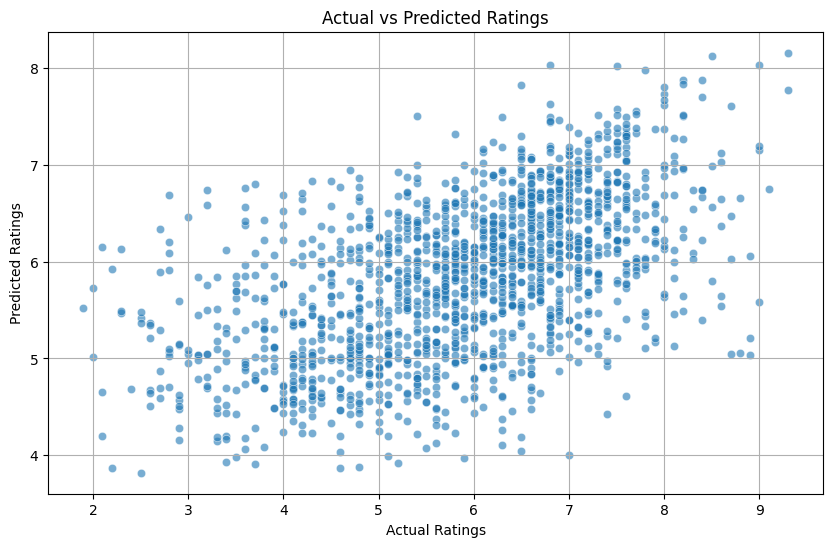

In [30]:
# 12. Plot Actual vs Predicted Ratings
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.grid(True)
plt.show()

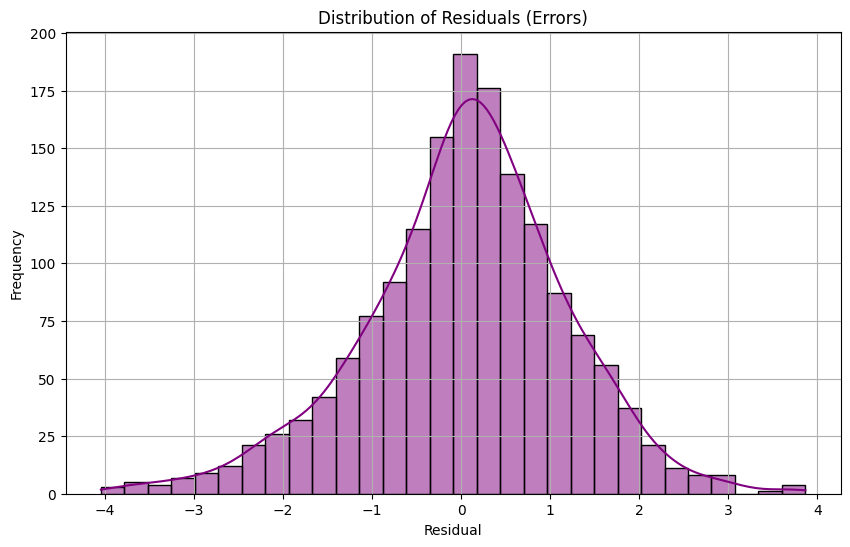

In [31]:
# 13. Plot Residuals
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()